In [1]:
# ── Cell 1: Raw material inputs ──────────────────────────────────────────────
# Material intensity: how many kg of each material you need per kWh of battery
# Illustrative assumptions informed by the structure of Argonne's BatPaC model.
# These values are not direct BatPaC exports or supplier-quote inputs.
kg_per_kwh = {
    "Lithium Carbonate": 0.42,
    "Iron Phosphate":    1.20,
    "Graphite":          0.65,
    "Electrolyte":       0.50,
    "Separator":         0.15,
    "Copper Foil":       0.17,
    "Aluminum Foil":     0.12,
    "Cell Housing":      0.25,
}

# Commodity prices in $/kg  (as of June 2026)
# Illustrative public-market assumptions; not executable supplier quotations.
price_per_kg = {
    "Lithium Carbonate": 10.50,
    "Iron Phosphate":     2.80,
    "Graphite":           0.90,
    "Electrolyte":        4.20,
    "Separator":         12.00,
    "Copper Foil":        9.50,
    "Aluminum Foil":      2.60,
    "Cell Housing":       3.00,
}

# Calculate cost per kWh for each material
material_costs = {}
for material in kg_per_kwh:
    material_costs[material] = kg_per_kwh[material] * price_per_kg[material]

# Print the breakdown
print(f"{'Material':<22} {'kg/kWh':>8} {'$/kg':>8} {'$/kWh':>8}")
print("-" * 50)
for material, cost in material_costs.items():
    print(f"{material:<22} {kg_per_kwh[material]:>8.2f} {price_per_kg[material]:>8.2f} {cost:>8.2f}")

print("-" * 50)
total_materials = sum(material_costs.values())
print(f"{'TOTAL MATERIALS':<22} {'':>8} {'':>8} {total_materials:>8.2f}")

Material                 kg/kWh     $/kg    $/kWh
--------------------------------------------------
Lithium Carbonate          0.42    10.50     4.41
Iron Phosphate             1.20     2.80     3.36
Graphite                   0.65     0.90     0.59
Electrolyte                0.50     4.20     2.10
Separator                  0.15    12.00     1.80
Copper Foil                0.17     9.50     1.62
Aluminum Foil              0.12     2.60     0.31
Cell Housing               0.25     3.00     0.75
--------------------------------------------------
TOTAL MATERIALS                             14.93


In [2]:
# ── Cell 2: Manufacturing / conversion costs ──────────────────────────────────
# These are the costs to actually build the cell: labor, energy, equipment
# Illustrative assumptions informed by published battery cost-model categories.
# A production model would calculate these from plant scale, utilization, yield,
# regional labor/energy rates, process time, and equipment life.

manufacturing = {
    "Labor":                 3.50,   # $/kWh — factory workers (hourly wage × workers needed) ÷ (cells produced per hour × kWh per cell).
    "Energy":                1.20,   # $/kWh — electricity to run the plant
    "Equipment Depreciation":4.80,   # $/kWh — cost of machines spread over their lifetime
    "Yield Loss":            1.50,   # $/kWh — cells that fail QC and get scrapped
}

total_manufacturing = sum(manufacturing.values())

print(f"{'Cost Item':<26} {'$/kWh':>8}")
print("-" * 36)
for item, cost in manufacturing.items():
    print(f"{item:<26} {cost:>8.2f}")
print("-" * 36)
print(f"{'TOTAL MANUFACTURING':<26} {total_manufacturing:>8.2f}")
print()
print(f"Materials:     ${total_materials:>6.2f}/kWh")
print(f"Manufacturing: ${total_manufacturing:>6.2f}/kWh")
print(f"               {'─'*10}")
print(f"Subtotal:      ${total_materials + total_manufacturing:>6.2f}/kWh")

Cost Item                     $/kWh
------------------------------------
Labor                          3.50
Energy                         1.20
Equipment Depreciation         4.80
Yield Loss                     1.50
------------------------------------
TOTAL MANUFACTURING           11.00

Materials:     $ 14.93/kWh
Manufacturing: $ 11.00/kWh
               ──────────
Subtotal:      $ 25.93/kWh


In [3]:
# ── Cell 3: Overhead and margin ───────────────────────────────────────────────
# Illustrative percentage adders. A sourcing model should validate these against
# the supplier's cost structure and avoid treating them as universal rates.

subtotal = total_materials + total_manufacturing

overhead_pct  = 0.15   # 15% — R&D, SG&A, facilities, quality
margin_pct    = 0.10   # 10% — supplier profit margin

overhead = subtotal * overhead_pct
margin   = subtotal * margin_pct
total    = subtotal + overhead + margin

print(f"{'Item':<26} {'$/kWh':>8} {'% of sub':>10}")
print("-" * 46)
print(f"{'Materials':<26} {total_materials:>8.2f}")
print(f"{'Manufacturing':<26} {total_manufacturing:>8.2f}")
print(f"{'Overhead (15%)':<26} {overhead:>8.2f} {overhead/subtotal*100:>9.1f}%")
print(f"{'Margin (10%)':<26} {margin:>8.2f} {margin/subtotal*100:>9.1f}%")
print("-" * 46)
print(f"{'TOTAL CELL COST':<26} {total:>8.2f}")
print(f"\nLFP cell should-cost: ${total:.2f}/kWh")

Item                          $/kWh   % of sub
----------------------------------------------
Materials                     14.93
Manufacturing                 11.00
Overhead (15%)                 3.89      15.0%
Margin (10%)                   2.59      10.0%
----------------------------------------------
TOTAL CELL COST               32.42

LFP cell should-cost: $32.42/kWh


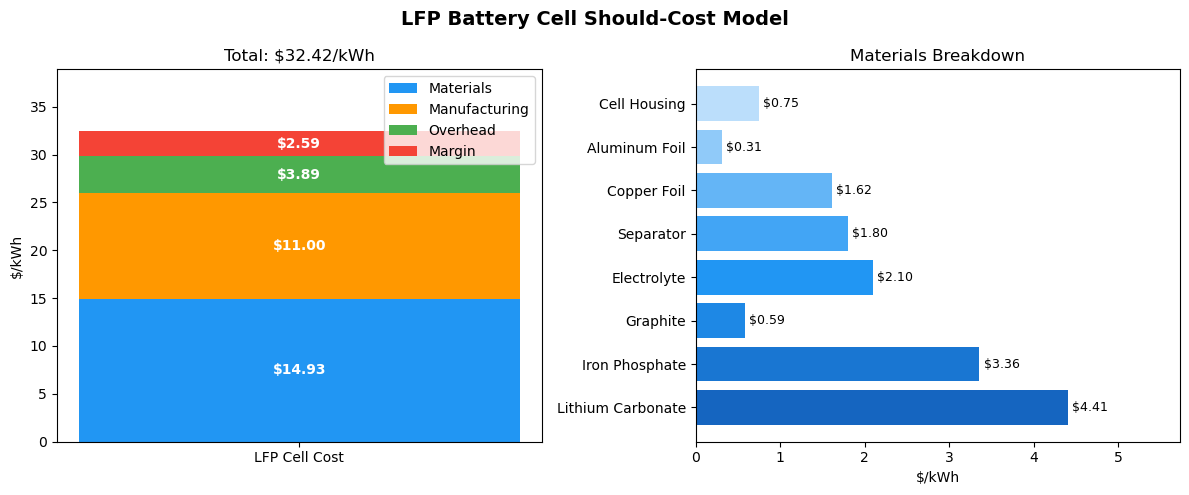

Chart saved as cost_breakdown.png


In [4]:
# ── Cell 4: Charts ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Chart 1: Cost stack (stacked bar) ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LFP Battery Cell Should-Cost Model", fontsize=14, fontweight="bold")

categories = ["LFP Cell Cost"]
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336"]
labels  = ["Materials", "Manufacturing", "Overhead", "Margin"]
values  = [total_materials, total_manufacturing, overhead, margin]

bottom = 0
for val, color, label in zip(values, colors, labels):
    ax1.bar(categories, val, bottom=bottom, color=color, label=label, width=0.4)
    ax1.text(0, bottom + val/2, f"${val:.2f}", ha="center", va="center",
             color="white", fontweight="bold", fontsize=10)
    bottom += val

ax1.set_ylabel("$/kWh")
ax1.set_title(f"Total: ${total:.2f}/kWh")
ax1.legend(loc="upper right")
ax1.set_ylim(0, total * 1.2)

# ── Chart 2: Materials breakdown (horizontal bar) ────────────────────────────
mat_names = list(material_costs.keys())
mat_vals  = list(material_costs.values())
mat_colors = ["#1565C0","#1976D2","#1E88E5","#2196F3","#42A5F5","#64B5F6","#90CAF9","#BBDEFB"]

bars = ax2.barh(mat_names, mat_vals, color=mat_colors)
ax2.set_xlabel("$/kWh")
ax2.set_title("Materials Breakdown")
for bar, val in zip(bars, mat_vals):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f"${val:.2f}", va="center", fontsize=9)
ax2.set_xlim(0, max(mat_vals) * 1.3)

plt.tight_layout()
plt.savefig("cost_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as cost_breakdown.png")

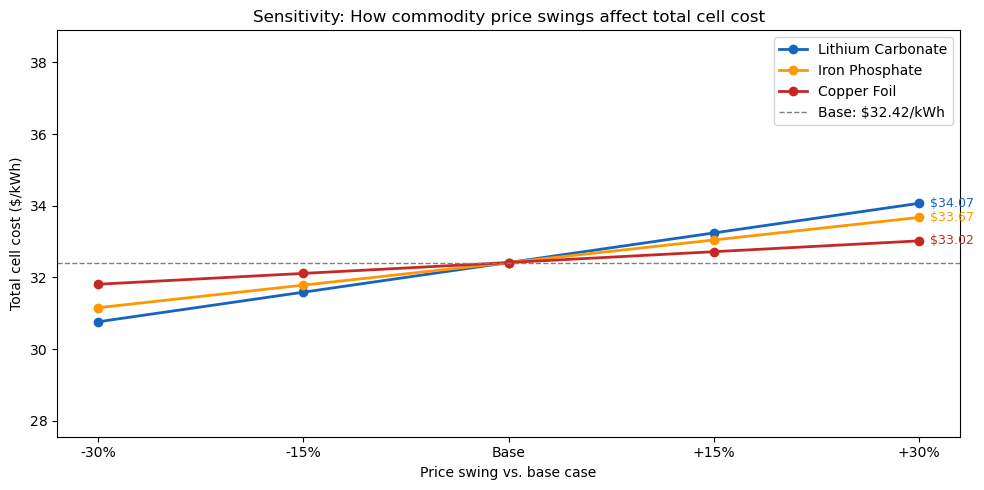

Chart saved as sensitivity.png


In [5]:
# ── Cell 5: Sensitivity analysis ─────────────────────────────────────────────
# Shows how total $/kWh moves when key commodity prices change
# This is what procurement analysts call a "price risk" or "should-cost bridge"

import numpy as np

# Three illustrative sourcing inputs selected for scenario analysis
sensitivity_inputs = {
    "Lithium Carbonate": {"base": 10.50, "swings": [-0.30, -0.15, 0, +0.15, +0.30]},
    "Iron Phosphate":    {"base":  2.80, "swings": [-0.30, -0.15, 0, +0.15, +0.30]},
    "Copper Foil":       {"base":  9.50, "swings": [-0.30, -0.15, 0, +0.15, +0.30]},
}

def compute_total(overrides={}):
    """Recompute total $/kWh with optional price overrides."""
    prices = price_per_kg.copy()
    prices.update(overrides)
    mats = sum(kg_per_kwh[m] * prices[m] for m in kg_per_kwh)
    sub  = mats + total_manufacturing
    return sub * (1 + overhead_pct + margin_pct)

fig, ax = plt.subplots(figsize=(10, 5))

swing_labels = ["-30%", "-15%", "Base", "+15%", "+30%"]
x = np.arange(len(swing_labels))
width = 0.25
offsets = [-width, 0, width]
colors  = ["#1565C0", "#FF9800", "#C62828"]

for i, (material, cfg) in enumerate(sensitivity_inputs.items()):
    totals = []
    for swing in cfg["swings"]:
        new_price = cfg["base"] * (1 + swing)
        totals.append(compute_total({material: new_price}))
    ax.plot(x, totals, marker="o", color=colors[i], label=material, linewidth=2)
    # Annotate the +30% end point
    ax.annotate(f"${totals[-1]:.2f}", xy=(x[-1], totals[-1]),
                xytext=(8, 0), textcoords="offset points",
                va="center", color=colors[i], fontsize=9)

ax.axhline(total, color="gray", linestyle="--", linewidth=1, label=f"Base: ${total:.2f}/kWh")
ax.set_xticks(x)
ax.set_xticklabels(swing_labels)
ax.set_xlabel("Price swing vs. base case")
ax.set_ylabel("Total cell cost ($/kWh)")
ax.set_title("Sensitivity: How commodity price swings affect total cell cost")
ax.legend()
ax.set_ylim(total * 0.85, total * 1.20)

plt.tight_layout()
plt.savefig("sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as sensitivity.png")

In [6]:
# ── Cell 6: Full summary ──────────────────────────────────────────────────────

print("=" * 52)
print("   LFP BATTERY CELL SHOULD-COST MODEL")
print("   Chemistry: Lithium Iron Phosphate (LFP)")
print("   As of: June 2026")
print("=" * 52)

print("\n── MATERIALS ──────────────────────────────────")
for material, cost in material_costs.items():
    print(f"  {material:<22} ${cost:>5.2f}/kWh")
print(f"  {'SUBTOTAL':<22} ${total_materials:>5.2f}/kWh")

print("\n── MANUFACTURING ──────────────────────────────")
for item, cost in manufacturing.items():
    print(f"  {item:<22} ${cost:>5.2f}/kWh")
print(f"  {'SUBTOTAL':<22} ${total_manufacturing:>5.2f}/kWh")

print("\n── OVERHEAD & MARGIN ──────────────────────────")
print(f"  {'Overhead (15%)':<22} ${overhead:>5.2f}/kWh")
print(f"  {'Margin (10%)':<22} ${margin:>5.2f}/kWh")

print("\n" + "=" * 52)
print(f"  TOTAL CELL COST          ${total:>5.2f}/kWh")
print("=" * 52)

print("\n── COST SPLIT ─────────────────────────────────")
print(f"  Materials:      {total_materials/total*100:.1f}%")
print(f"  Manufacturing:  {total_manufacturing/total*100:.1f}%")
print(f"  Overhead:       {overhead/total*100:.1f}%")
print(f"  Margin:         {margin/total*100:.1f}%")

print("\n── SANITY CHECK / LIMITATION ──────────────────")
partial_pack_estimate = total * 1.25
bnef_lfp_pack_2025 = 81.00
bnef_stationary_pack_2025 = 70.00
print(f"  Illustrative cell cost:       ${total:.2f}/kWh")
print(f"  Partial pack est. (1.25x):    ${partial_pack_estimate:.2f}/kWh")
print(f"  BNEF 2025 avg. LFP pack:      ${bnef_lfp_pack_2025:.2f}/kWh")
print(f"  BNEF 2025 stationary pack:    ${bnef_stationary_pack_2025:.2f}/kWh")
print("  Conclusion: the partial pack estimate is below both market benchmarks,")
print("  which indicates omitted integration/process/commercial costs. It is not")
print("  a validated supplier quote or a like-for-like market-price estimate.")

   LFP BATTERY CELL SHOULD-COST MODEL
   Chemistry: Lithium Iron Phosphate (LFP)
   As of: June 2026

── MATERIALS ──────────────────────────────────
  Lithium Carbonate      $ 4.41/kWh
  Iron Phosphate         $ 3.36/kWh
  Graphite               $ 0.59/kWh
  Electrolyte            $ 2.10/kWh
  Separator              $ 1.80/kWh
  Copper Foil            $ 1.62/kWh
  Aluminum Foil          $ 0.31/kWh
  Cell Housing           $ 0.75/kWh
  SUBTOTAL               $14.93/kWh

── MANUFACTURING ──────────────────────────────
  Labor                  $ 3.50/kWh
  Energy                 $ 1.20/kWh
  Equipment Depreciation $ 4.80/kWh
  Yield Loss             $ 1.50/kWh
  SUBTOTAL               $11.00/kWh

── OVERHEAD & MARGIN ──────────────────────────
  Overhead (15%)         $ 3.89/kWh
  Margin (10%)           $ 2.59/kWh

  TOTAL CELL COST          $32.42/kWh

── COST SPLIT ─────────────────────────────────
  Materials:      46.1%
  Manufacturing:  33.9%
  Overhead:       12.0%
  Margin:       